<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/Tonyong/graph1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โหลดไฟล์ข้อมูลการเคลม

In [ ]:
import pandas as pd
import warnings
import matplotlib.font_manager as fm
import seaborn as sns

warnings.filterwarnings('ignore')

# (มีข้อมูลลูกค้าและกรมธรรม์อยู่แล้ว)
df_claims = pd.read_csv("claims_system.csv")

# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format

In [ ]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

In [ ]:
# คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

q1_df = (df_claims.groupby("insurance_type").agg(
        total_net_payout = ("net_payout", "sum"),
        avg_claim_amount = ("claim_amount", "mean"),).sort_values(by="total_net_payout", ascending=False))
display(q1_df)

,total_net_payout,avg_claim_amount
insurance_type,,
ประกันชีวิต,"137,857,500.00","1,071,699.13"
ประกันโรคร้ายแรง,"81,972,000.00","664,804.59"
ประกันสุขภาพ,"26,216,579.78","469,881.22"
ประกันอุบัติเหตุ,"19,886,779.63","325,320.82"


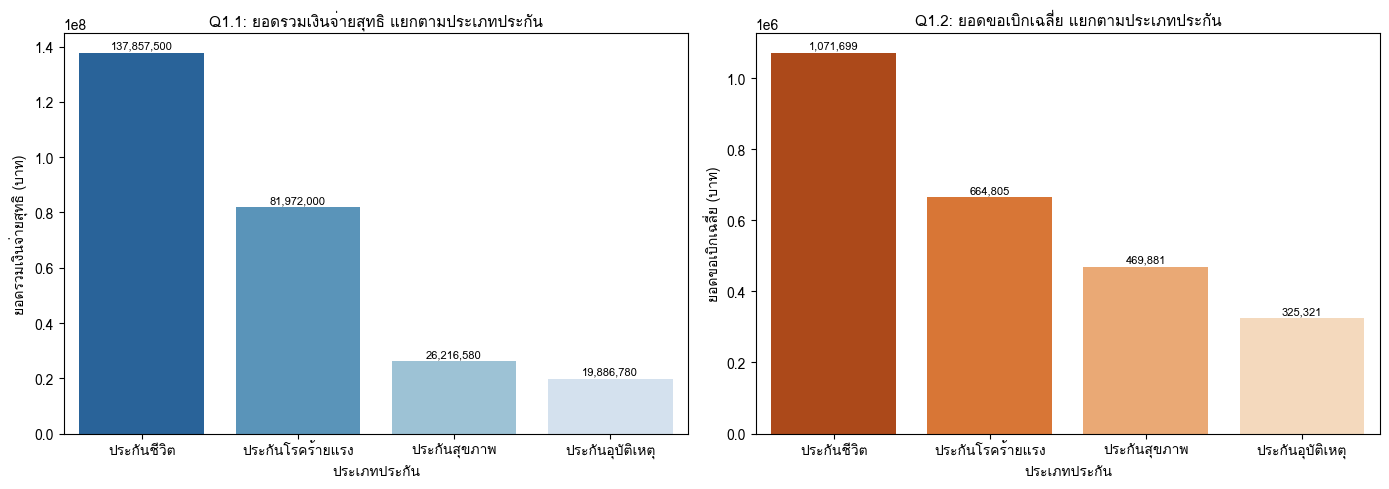

In [ ]:
# กราฟข้อที่ 1
q1_df = pd.DataFrame({
    'insurance_type': ['ประกันชีวิต', 'ประกันโรคร้ายแรง', 'ประกันสุขภาพ', 'ประกันอุบัติเหตุ'],
    'total_net_payout': [137857500.00, 81972000.00, 26216579.78, 19886779.63],
    'avg_claim_amount': [1071699.13, 664804.59, 469881.22, 325320.82]
}).set_index('insurance_type')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar ยอดรวม (ซ้าย)
ax1 = sns.barplot(x=q1_df.index, y=q1_df['total_net_payout'], hue=q1_df.index, palette='Blues_r', ax=axes[0], legend=False)
axes[0].set_title('Q1.1: ยอดรวมเงินจ่ายสุทธิ แยกตามประเภทประกัน', fontsize=11, fontweight='bold')
axes[0].set_xlabel('ประเภทประกัน')
axes[0].set_ylabel('ยอดรวมเงินจ่ายสุทธิ (บาท)')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

# Bar ค่าเฉลี่ย (ขวา)
ax2 = sns.barplot(x=q1_df.index, y=q1_df['avg_claim_amount'], hue=q1_df.index, palette='Oranges_r', ax=axes[1], legend=False)
axes[1].set_title('Q1.2: ยอดขอเบิกเฉลี่ย แยกตามประเภทประกัน', fontsize=11, fontweight='bold')
axes[1].set_xlabel('ประเภทประกัน')
axes[1].set_ylabel('ยอดขอเบิกเฉลี่ย (บาท)')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()